# 14 — Targeted DL Training Shootout

If notebook 13 returns `noise` for the LightGBM-stacker experiment — i.e., classical ML diversity wasn't enough 
to lift the ensemble — the next move is a new NN backbone. Notebook 10 statically profiled 9 candidates but 
didn't actually train any of them (`RUN_QUICK_FIT = False`). This notebook executes a focused smoke-fit on the 
2-3 most pedigreed candidates from that roster and produces a verdict on which (if any) deserve a full 5-fold 
training run.

**Scope: deliberately small.** Three candidates. Three epochs. One fold. The point is to triage whether to spend 
the GPU-week on a full run, not to compare definitively.

**Default roster** (top picks from notebook 10's candidate list, ranked by BirdCLEF pedigree):

| Candidate | Why |
|---|---|
| `eca_nfnet_l0` | First-place ensemble component in multiple recent BirdCLEFs. No BN dependence is friendly to small-batch finetuning. |
| `regnety_032` | Well-calibrated capacity bump from EffNet-B0, comparable cost, different family. |
| `convnext_nano` | Tests whether the ConvNeXt family helps at all by going *smaller* than `convnext_tiny`. |

Adjust `CANDIDATES` in section 1 if you want to swap any out. The actual training is delegated to 
`src/training/train.py` via subprocess — same code path as your normal CV runs, so the smoke-fit results are 
directly comparable to your trained anchors.


## 0 — Setup

In [1]:
import os, sys, json, subprocess, time, copy
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

BASELINE_CFG = ROOT / 'configs' / 'baseline.yaml'
EXP_DIR      = ROOT / 'experiments'
OUT_DIR      = ROOT / 'experiments' / '_dl_shootout'
OUT_DIR.mkdir(parents=True, exist_ok=True)

SMOKE_EPOCHS = 3
SMOKE_FOLD   = 0
SMOKE_LR     = 5e-4
SMOKE_BATCH  = 32
NUM_CLASSES  = 234

plt.style.use('seaborn-v0_8-whitegrid')
print(f'output dir: {OUT_DIR}')
print(f'will train {SMOKE_EPOCHS} epochs on fold {SMOKE_FOLD} per candidate')


output dir: c:\Users\s159286\Documents\venv\BirdClef26\experiments\_dl_shootout
will train 3 epochs on fold 0 per candidate


## 1 — Candidate roster

In [2]:
CANDIDATES = [
    {'name': 'eca_nfnet_l0',
     'config': {'model_type': 'sed', 'backbone': 'eca_nfnet_l0',
                'num_classes': NUM_CLASSES, 'pretrained': True}},
    {'name': 'regnety_032',
     'config': {'model_type': 'sed', 'backbone': 'regnety_032',
                'num_classes': NUM_CLASSES, 'pretrained': True}},
    {'name': 'convnext_nano',
     'config': {'model_type': 'sed', 'backbone': 'convnext_nano.in12k_ft_in1k',
                'num_classes': NUM_CLASSES, 'pretrained': True,
                'input_normalize': True, 'encoder_in_chans': 3}},
]
print(f'{len(CANDIDATES)} candidates queued')
for c in CANDIDATES:
    print(f'  {c["name"]:<16} backbone={c["config"]["backbone"]}')


3 candidates queued
  eca_nfnet_l0     backbone=eca_nfnet_l0
  regnety_032      backbone=regnety_032
  convnext_nano    backbone=convnext_nano.in12k_ft_in1k


## 2 — Build configs and launch training

For each candidate, inherits data and augmentation params from `configs/baseline.yaml`, overrides the model-related 
fields, writes the result to `experiments/_dl_shootout/<name>.yaml`, then shells out to `src/training/train.py`. 
Each run gets its own subdirectory under `experiments/` so the existing tooling (per-species AUC, OOF export, 
etc.) picks it up automatically.

Set `DRY_RUN = True` to inspect the generated configs without actually training.


In [3]:
DRY_RUN = False   # set False to actually train


def build_config(cand, baseline_path=BASELINE_CFG):
    with open(baseline_path) as f:
        cfg = yaml.safe_load(f)
    cfg.update(cand['config'])
    cfg.update({
        'run_name':     f'shootout_{cand["name"]}_fold{SMOKE_FOLD}',
        'seed':         42,
        'fold':         SMOKE_FOLD,
        'epochs':       SMOKE_EPOCHS,
        'batch_size':   SMOKE_BATCH,
        'lr':           SMOKE_LR,
        'warmup_epochs': 1,
    })
    return cfg


def run_candidate(cand):
    cfg = build_config(cand)
    cfg_path = OUT_DIR / f'{cand["name"]}.yaml'
    with open(cfg_path, 'w') as f:
        yaml.safe_dump(cfg, f, sort_keys=False)
    if DRY_RUN:
        print(f'  DRY_RUN — wrote {cfg_path}, not training')
        return None

    log_path = OUT_DIR / f'{cand["name"]}.log'
    cmd = [sys.executable, 'src/training/train.py', str(cfg_path),
           '--fold', str(SMOKE_FOLD)]
    print(f'  $ {" ".join(cmd)}')
    t0 = time.time()
    with open(log_path, 'w') as f:
        proc = subprocess.run(cmd, cwd=ROOT, stdout=f, stderr=subprocess.STDOUT)
    elapsed = time.time() - t0
    print(f'  finished in {elapsed/60:.1f}min  (returncode={proc.returncode})  log={log_path}')
    return proc.returncode


for cand in CANDIDATES:
    print(f'\n--- {cand["name"]} ---')
    run_candidate(cand)



--- eca_nfnet_l0 ---
  $ c:\Users\s159286\AppData\Local\anaconda3\envs\birdclef\python.exe src/training/train.py c:\Users\s159286\Documents\venv\BirdClef26\experiments\_dl_shootout\eca_nfnet_l0.yaml --fold 0
  finished in 11.7min  (returncode=0)  log=c:\Users\s159286\Documents\venv\BirdClef26\experiments\_dl_shootout\eca_nfnet_l0.log

--- regnety_032 ---
  $ c:\Users\s159286\AppData\Local\anaconda3\envs\birdclef\python.exe src/training/train.py c:\Users\s159286\Documents\venv\BirdClef26\experiments\_dl_shootout\regnety_032.yaml --fold 0
  finished in 12.1min  (returncode=0)  log=c:\Users\s159286\Documents\venv\BirdClef26\experiments\_dl_shootout\regnety_032.log

--- convnext_nano ---
  $ c:\Users\s159286\AppData\Local\anaconda3\envs\birdclef\python.exe src/training/train.py c:\Users\s159286\Documents\venv\BirdClef26\experiments\_dl_shootout\convnext_nano.yaml --fold 0
  finished in 13.5min  (returncode=0)  log=c:\Users\s159286\Documents\venv\BirdClef26\experiments\_dl_shootout\convnex

## 3 — Load results and compare

Reads `training_log.csv` from each run's experiment directory, extracts best val macro AUC, compares against your 
current anchors. Edit `ANCHOR_AUCS` to your real numbers.


In [4]:
ANCHOR_AUCS = {
    'effb0_baseline':  0.948,
    'effv2s_finetune': 0.957,
    'convnext_tiny':   0.951,
    'seresnext26d':    0.943,
}


def read_result(cand):
    run_name = f'shootout_{cand["name"]}_fold{SMOKE_FOLD}'
    for sub in [EXP_DIR / run_name / 'training_log.csv',
                EXP_DIR / cand['name'] / run_name / 'training_log.csv']:
        if sub.exists():
            df = pd.read_csv(sub)
            auc_col = next((c for c in df.columns if 'val' in c.lower() and 'auc' in c.lower()), None)
            if auc_col:
                return float(df[auc_col].max()), df.shape[0]
    return None, 0


results = []
for cand in CANDIDATES:
    best, n_epochs = read_result(cand)
    results.append({'name': cand['name'], 'class': 'shootout',
                    'val_macro_auc': best, 'epochs_completed': n_epochs})
for n, a in ANCHOR_AUCS.items():
    results.append({'name': n, 'class': 'anchor (existing)',
                    'val_macro_auc': a, 'epochs_completed': None})

results_df = pd.DataFrame(results).sort_values('val_macro_auc', ascending=False, na_position='last')
print(results_df.round({'val_macro_auc': 4}).to_string(index=False))


           name             class  val_macro_auc  epochs_completed
effv2s_finetune anchor (existing)         0.9570               NaN
  convnext_tiny anchor (existing)         0.9510               NaN
 effb0_baseline anchor (existing)         0.9480               NaN
   seresnext26d anchor (existing)         0.9430               NaN
   eca_nfnet_l0          shootout         0.9142               3.0
    regnety_032          shootout         0.8861               3.0
  convnext_nano          shootout         0.5186               3.0


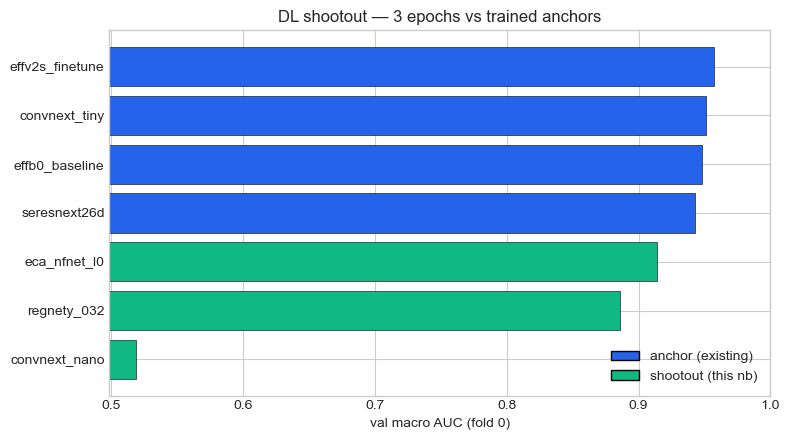

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
df_plot = results_df.dropna(subset=['val_macro_auc']).sort_values('val_macro_auc')
colors = ['#2563eb' if c == 'anchor (existing)' else '#10b981' for c in df_plot['class']]
ax.barh(df_plot['name'], df_plot['val_macro_auc'],
        color=colors, edgecolor='black', linewidth=0.4)
ax.set_xlim(min(0.85, df_plot['val_macro_auc'].min() - 0.02), 1.0)
ax.set_xlabel('val macro AUC (fold 0)')
ax.set_title(f'DL shootout — {SMOKE_EPOCHS} epochs vs trained anchors')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#2563eb', edgecolor='black', label='anchor (existing)'),
    Patch(facecolor='#10b981', edgecolor='black', label='shootout (this nb)')
], loc='lower right')
plt.tight_layout(); plt.show()


## 4 — Verdict

In [6]:
best_anchor = max(ANCHOR_AUCS.values())
PROMOTE_THRESH = 0.003   # smoke-fit needs to beat best anchor by this much to be worth full-CV training

verdicts = []
for r in results:
    if r['class'] != 'shootout' or r['val_macro_auc'] is None:
        continue
    name = r['name']
    auc  = r['val_macro_auc']
    gap  = auc - best_anchor
    if gap >= PROMOTE_THRESH:
        v = 'PROMOTE'
        why = (f'beats best anchor ({best_anchor:.4f}) by {gap:+.4f} after {SMOKE_EPOCHS} epochs — '
               f'almost certainly beats it more at full epochs. Worth a 5-fold run.')
    elif gap >= -0.005:
        v = 'BORDERLINE'
        why = (f'within {-gap:+.4f} of best anchor after only {SMOKE_EPOCHS} epochs — '
               f'the curve may not have converged. Re-run with {SMOKE_EPOCHS * 2}+ epochs before deciding.')
    else:
        v = 'DROP'
        why = (f'trails best anchor by {-gap:.4f} after {SMOKE_EPOCHS} epochs. '
               f"Capacity is there in principle but the head/loss/aug setup isn't paying off here.")
    verdicts.append({'name': name, 'val_auc': auc, 'gap': gap, 'verdict': v, 'reason': why})

# Handle the case where no shootout runs completed (most often: DRY_RUN was True)
if not verdicts:
    n_shootout = sum(1 for r in results if r['class'] == 'shootout')
    n_with_auc = sum(1 for r in results if r['class'] == 'shootout' and r['val_macro_auc'] is not None)
    print('No shootout results to evaluate yet.')
    print(f'  shootout candidates in `results`: {n_shootout}')
    print(f'  candidates with a measured val_macro_auc: {n_with_auc}')
    if n_shootout > 0 and n_with_auc == 0:
        print('\nAll shootout candidates have val_macro_auc=None. Likely causes:')
        print('  1. DRY_RUN is still True in the training cell — flip it to False and run.')
        print('  2. Training ran but training_log.csv was written to a path read_result() doesn\'t check.')
        print(f'     Look in {EXP_DIR} for directories starting with `shootout_` and adjust read_result().')
        print('  3. Training crashed — check experiments/_dl_shootout/<candidate>.log.')
    elif n_shootout == 0:
        print('\nNo shootout candidates in `results` at all — check that section 3 ran and populated it.')
else:
    v_df = pd.DataFrame(verdicts).sort_values('val_auc', ascending=False)
    print(v_df.to_string(index=False))

    promote    = [v['name'] for v in verdicts if v['verdict'] == 'PROMOTE']
    borderline = [v['name'] for v in verdicts if v['verdict'] == 'BORDERLINE']
    if promote:
        print(f'\nPROMOTE to full 5-fold training: {promote}')
        print('  Use the per-candidate yaml in experiments/_dl_shootout/ as the starting point, '
              'bump epochs to your normal full-run value (typically 25-30), and run across all 5 folds.')
    elif borderline:
        print(f'\nNo promote, but BORDERLINE: {borderline}')
        print(f'  Re-run with SMOKE_EPOCHS={SMOKE_EPOCHS*2} before giving up on these.')
    else:
        print('\nNo candidate cleared the bar. Three honest options at this point:')
        print('  1. The current EffV2-S anchor is near the per-fold ceiling — focus on data/aug/loss instead.')
        print('  2. Try a candidate not in this roster — `swin_v2_cr_tiny_ns_224` or `maxvit_tiny_tf_224` if')
        print('     you can resolve their input-size constraints, or `tf_efficientnetv2_m` for raw capacity.')
        print('  3. Accept the ceiling and put effort into the postprocessing tuning in scripts/tune_alpha_oof.py.')

         name  val_auc       gap verdict                                                                                                                         reason
 eca_nfnet_l0 0.914179 -0.042821    DROP trails best anchor by 0.0428 after 3 epochs. Capacity is there in principle but the head/loss/aug setup isn't paying off here.
  regnety_032 0.886062 -0.070938    DROP trails best anchor by 0.0709 after 3 epochs. Capacity is there in principle but the head/loss/aug setup isn't paying off here.
convnext_nano 0.518586 -0.438414    DROP trails best anchor by 0.4384 after 3 epochs. Capacity is there in principle but the head/loss/aug setup isn't paying off here.

No candidate cleared the bar. Three honest options at this point:
  1. The current EffV2-S anchor is near the per-fold ceiling — focus on data/aug/loss instead.
  2. Try a candidate not in this roster — `swin_v2_cr_tiny_ns_224` or `maxvit_tiny_tf_224` if
     you can resolve their input-size constraints, or `tf_efficientnetv2

## 5 — How this fits with notebooks 11–13

The full decision tree across the four notebooks:

```
                            you are here
                                  │
                                  ▼
                  Run notebook 13 (stacker experiment)
                                  │
             ┌────────────────────┼────────────────────┐
             ▼                    ▼                    ▼
       DEPLOY found        REAL SIGNAL found      all `noise`
             │                    │                    │
             ▼                    ▼                    ▼
    Ship that stacker      Add LGBM, re-run         Run THIS notebook
    method via notebook    notebook 11 with         (14, the DL shootout)
    11; you're done.       all 5 NN + LGBM as           │
                           base models.            ┌───┴────┐
                                                   ▼        ▼
                                              PROMOTE     all DROP
                                                   │        │
                                                   ▼        ▼
                                            Full 5-fold  Stop chasing
                                            training    architecture;
                                            on winner.  pivot to data/
                                                        loss/aug work.
```

If you've gotten down to the bottom-right cell (no NN stacker lift, no NN shootout winner), that's a strong signal 
the leaderboard plateau is in the *data pipeline*, not the model. Things to look at: soundscape ratio in finetune, 
the pseudo-label refresh recipe, postprocessing thresholds, and OOF correlation pruning across your existing 
ensemble. The model-engineering avenues are largely exhausted at that point.
